# Metabolite Catalog Exploration

**File**: `human_database_merge_unique_metab_with_HMDB_Info.csv`  
**Goal**: Characterize the consolidated, non-redundant metabolite list and assess its coverage, chemical diversity, and database provenance — laying the groundwork for downstream cancer cell-cell communication analysis.

---

## 1. Environment Setup

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

In [82]:
# ==========================================
# ⚙️ USER PARAMETERS (Export Options)
# ==========================================
# Full Notebook HTML Report Export Toggle:
# - True  -> Automatically exports the entire notebook (Markdown, Code, Tables, Figures) to styled HTML
# - False -> Disables automatic HTML export
SAVE_AS_HTML = False  # DEFAULT: False. Change to True to export the entire notebook!

## 2. Load Data

In [83]:
data_path = '../output/human_database_merge_unique_metab_with_HMDB_Info.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded: {len(df):,} unique metabolites, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 401 unique metabolites, 10 columns
Columns: ['Metabolite_Name', 'database', 'databases_count', 'HMDB_ID', 'HMDB_Name', 'SMILES', 'INCHIKEY', 'CHEMICAL_FORMULA', 'AVERAGE_MASS', 'MONO_MASS']


,Metabolite_Name,database,databases_count,HMDB_ID,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS
0,(r)-5-diphosphomevalonic acid,"CELLINKER2, MEBOCOST, MRCLINKDB",3,HMDB0001090,(R)-5-Diphosphomevalonic acid,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,SIGQQUBJQXSAMW-ZCFIWIBFSA-N,C6H14O10P2,308.1169,308.006220
1,(r)-lipoic acid,METALIGAND,1,HMDB0001451,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521
2,"1,25-dihydroxyvitamin d3-26,23-lactone","CELLINKER2, MRCLINKDB",2,HMDB0000969,"1,25-Dihydroxyvitamin D3-26,23-lactone",[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,WMYIVSWWSRCZFA-RWVJFQLJSA-N,C27H40O5,444.6035,444.287574
3,1-methylhistamine,METALIGAND,1,HMDB0000898,1-Methylhistamine,CN1C=NC(CCN)=C1,FHQDWPCFSJMNCT-UHFFFAOYSA-N,C6H11N3,125.1716,125.095297
4,11-cis-retinol,"CELLINKER2, MEBOCOST, MRCLINKDB",3,HMDB0006216,11-cis-Retinol,C\C(=C/CO)\C=C/C=C(\C)/C=C/C1=C(C)CCCC1(C)C,FPIPGXGPPPQFEQ-IOUUIBBYSA-N,C20H30O,286.4516,286.229666


## 3. Data Completeness Overview

How complete is each field across the 401 metabolites?

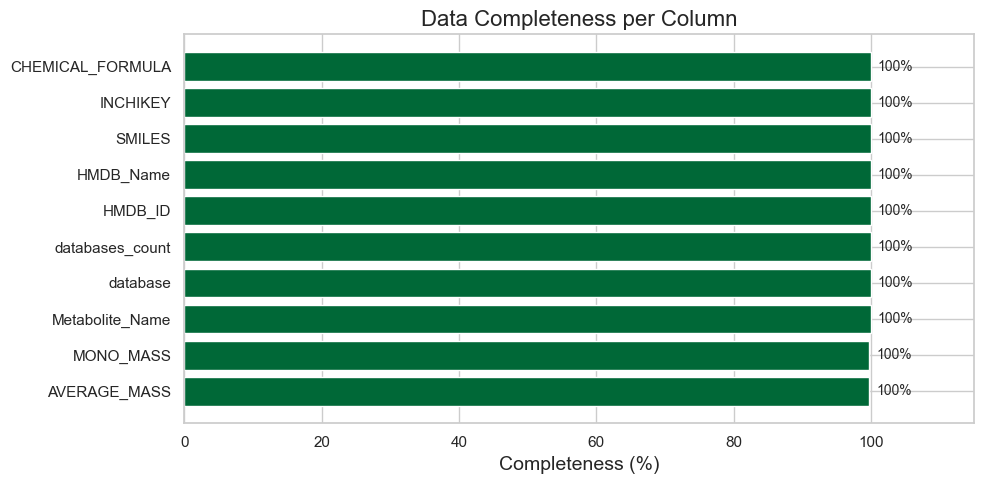

In [84]:
completeness = (df.notna().sum() / len(df) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness.index, completeness.values, color=plt.cm.RdYlGn(completeness.values / 100))
ax.set_xlabel('Completeness (%)')
ax.set_title('Data Completeness per Column')
for bar, val in zip(bars, completeness.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

---

## 4. Database Provenance

### 4.1. Cross-Database Validation
Metabolites supported by more databases have higher confidence.

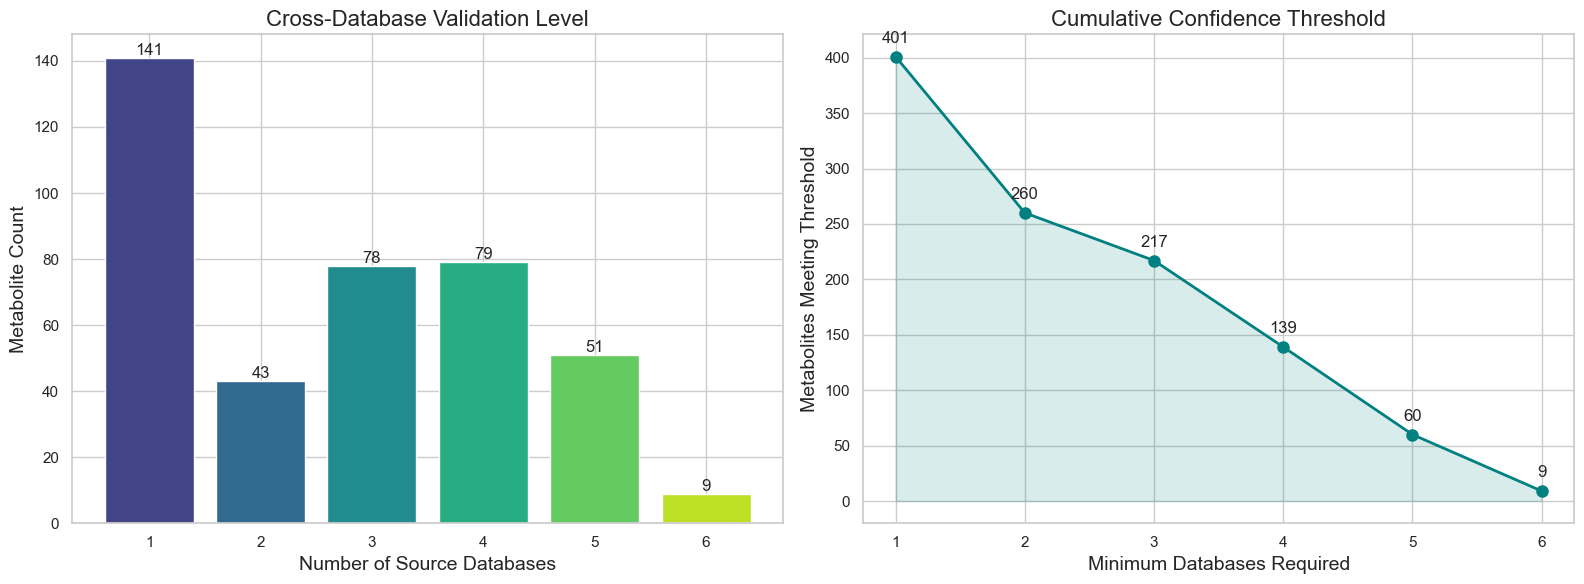


→ 217 metabolites (54.1%) are supported by 3+ databases (high confidence).
→ 141 metabolites (35.2%) are unique to a single database.


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count distribution
ax = axes[0]
vc = df['databases_count'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vc)))
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white')
for b in bars:
    ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2., b.get_height()),
                ha='center', va='bottom', fontsize=12)
ax.set_xlabel('Number of Source Databases')
ax.set_ylabel('Metabolite Count')
ax.set_title('Cross-Database Validation Level')

# Right: Cumulative confidence
ax2 = axes[1]
cumul = vc.iloc[::-1].cumsum().iloc[::-1]
ax2.plot(cumul.index, cumul.values, 'o-', color='teal', markersize=8, linewidth=2)
ax2.fill_between(cumul.index, cumul.values, alpha=0.15, color='teal')
ax2.set_xlabel('Minimum Databases Required')
ax2.set_ylabel('Metabolites Meeting Threshold')
ax2.set_title('Cumulative Confidence Threshold')
for x, y in zip(cumul.index, cumul.values):
    ax2.annotate(f'{y}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print(f'\n→ {(df["databases_count"] >= 3).sum()} metabolites ({(df["databases_count"] >= 3).mean()*100:.1f}%) are supported by 3+ databases (high confidence).')
print(f'→ {(df["databases_count"] == 1).sum()} metabolites ({(df["databases_count"] == 1).mean()*100:.1f}%) are unique to a single database.')

In [86]:
print("These are the metabolites mentioned in all 6 databases checked:")
df[(df["databases_count"] >= 6)]

These are the metabolites mentioned in all 6 databases checked:


,Metabolite_Name,database,databases_count,HMDB_ID,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS
91,androstenedione,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000053,Androstenedione,[H][C@@]12CCC(=O)[C@@]1(C)CC[C@@]1([H])[C@@]2(...,AEMFNILZOJDQLW-QAGGRKNESA-N,C19H26O2,286.4085,286.193280
116,cholesterol,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000067,Cholesterol,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,HVYWMOMLDIMFJA-DPAQBDIFSA-N,C27H46O,386.6535,386.354866
182,estradiol,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000151,Estradiol,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@]1([H])C3=C(...,VOXZDWNPVJITMN-ZBRFXRBCSA-N,C18H24O2,272.3820,272.177630
211,glycine,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000123,Glycine,NCC(O)=O,DHMQDGOQFOQNFH-UHFFFAOYSA-N,C2H5NO2,75.0666,75.032028
222,histamine,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000870,Histamine,NCCC1=CNC=N1,NTYJJOPFIAHURM-UHFFFAOYSA-N,C5H9N3,111.1451,111.079647
248,l-glutamate,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000148,Glutamic acid,N[C@@H](CCC(O)=O)C(O)=O,WHUUTDBJXJRKMK-VKHMYHEASA-N,C5H9NO4,147.1293,147.053158
324,progesterone,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0001830,Progesterone,[H][C@@]12CC[C@H](C(C)=O)[C@@]1(C)CC[C@@]1([H]...,RJKFOVLPORLFTN-LEKSSAKUSA-N,C21H30O2,314.4617,314.224580
348,serotonin,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000259,Serotonin,NCCC1=CNC2=C1C=C(O)C=C2,QZAYGJVTTNCVMB-UHFFFAOYSA-N,C10H12N2O,176.2151,176.094963
365,testosterone,"CELLINKER2, CELLPHONEDBV5, MEBOCOST, METALIGAN...",6,HMDB0000234,Testosterone,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@@]1([H])[C@@...,MUMGGOZAMZWBJJ-DYKIIFRCSA-N,C19H28O2,288.4244,288.208930


### 4.2. Individual Database Contributions

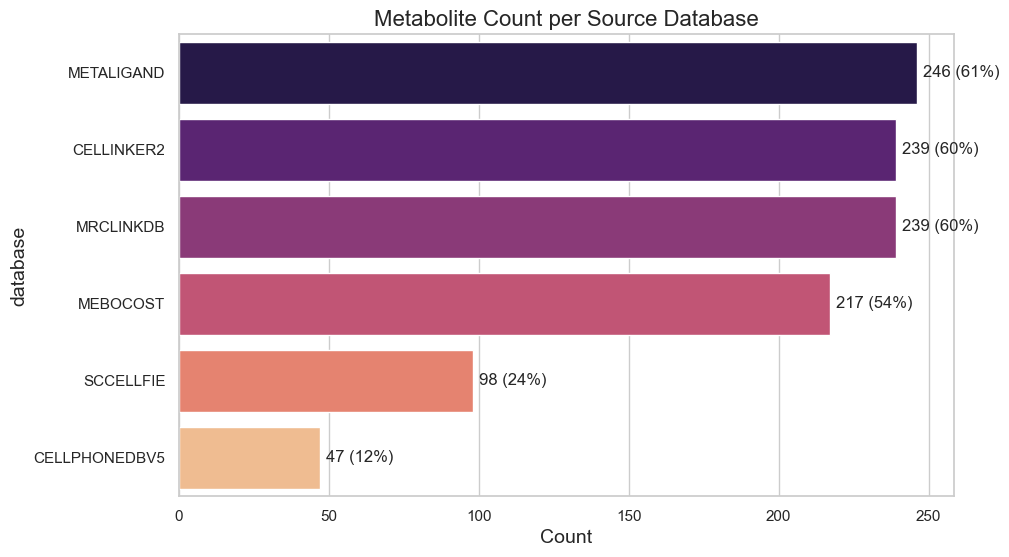

In [87]:
db_series = df['database'].str.split(', ').explode()
db_counts = db_series.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=db_counts.values, y=db_counts.index, hue=db_counts.index, palette='magma', legend=False)
plt.title('Metabolite Count per Source Database')
plt.xlabel('Count')
for i, v in enumerate(db_counts.values):
    plt.text(v + 2, i, f'{v} ({v/len(df)*100:.0f}%)', va='center')
plt.show()

#### Note on Cellinker2 and MRCLinkDB Overlap
In the merged dataset, **Cellinker2** and **MRCLinkDB** often show 100% overlap and zero exclusive metabolites in the counts below. This is an expected result of the pipeline logic in `merge_dbs_claude.py`, which identifies metabolites shared between these two sources and combines them into single entries (marked as `MRCLinkDB/Cellinker2`). Consequently, while they both contribute significant data, they appear as a joint set in the unique metabolite mapping.

### 4.3. Pairwise Database Overlap (Co-occurrence Matrix)
Which databases share the most metabolites?

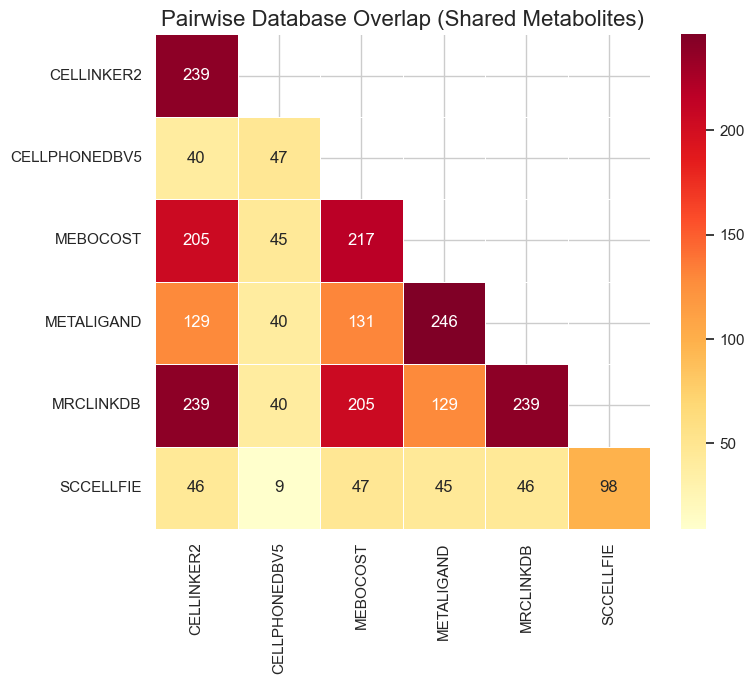


=== Database-Exclusive Metabolites ===
  CELLINKER2: 0 exclusive metabolites
  CELLPHONEDBV5: 1 exclusive metabolites
  MEBOCOST: 2 exclusive metabolites
  METALIGAND: 99 exclusive metabolites
  MRCLINKDB: 0 exclusive metabolites
  SCCELLFIE: 39 exclusive metabolites


In [88]:
# Build binary presence matrix
db_list = df['database'].str.split(', ')
all_dbs = sorted(db_series.unique())
presence = pd.DataFrame({db: db_list.apply(lambda x: db in x) for db in all_dbs})

# Overlap matrix (cast to int to ensure correct integer counts)
overlap = presence.astype(int).T.dot(presence.astype(int))

# Plot
mask = np.triu(np.ones_like(overlap, dtype=bool), k=1)
plt.figure(figsize=(8, 7))
sns.heatmap(overlap, annot=True, fmt='d', cmap='YlOrRd', mask=mask, linewidths=0.5,
            xticklabels=all_dbs, yticklabels=all_dbs)
plt.title('Pairwise Database Overlap (Shared Metabolites)')
plt.tight_layout()
plt.show()

# Unique metabolites per database
print('\n=== Database-Exclusive Metabolites ===')
for db in all_dbs:
    exclusive = presence[presence[db] & (presence.sum(axis=1) == 1)]
    print(f'  {db}: {len(exclusive)} exclusive metabolites')

---

## 5. HMDB Annotation Coverage

401/401 metabolites have HMDB identifiers.


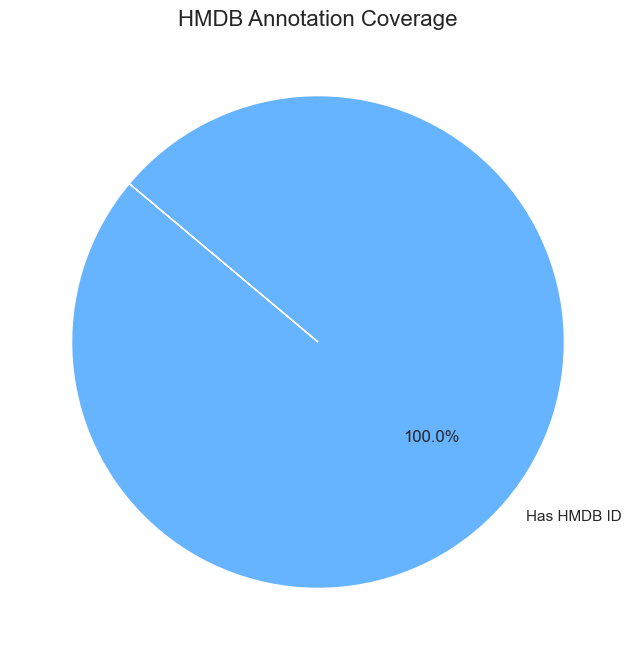

In [89]:
hmdb_counts = df['HMDB_ID'].notna().value_counts()
labels = [('Has HMDB ID' if i else 'Missing HMDB ID') for i in hmdb_counts.index]
explode = [0.05] * len(hmdb_counts) if len(hmdb_counts) > 1 else [0]
print(f'{hmdb_counts.get(True, 0)}/{len(df)} metabolites have HMDB identifiers.')
plt.figure(figsize=(8, 8))
plt.pie(hmdb_counts, labels=labels, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff9999'], explode=explode)
plt.title('HMDB Annotation Coverage')
plt.show()



---

## 6. Chemical Space Characterization

### 6.1. Molecular Weight Distribution
Small molecules (<500 Da) are typical metabolite signaling ligands.

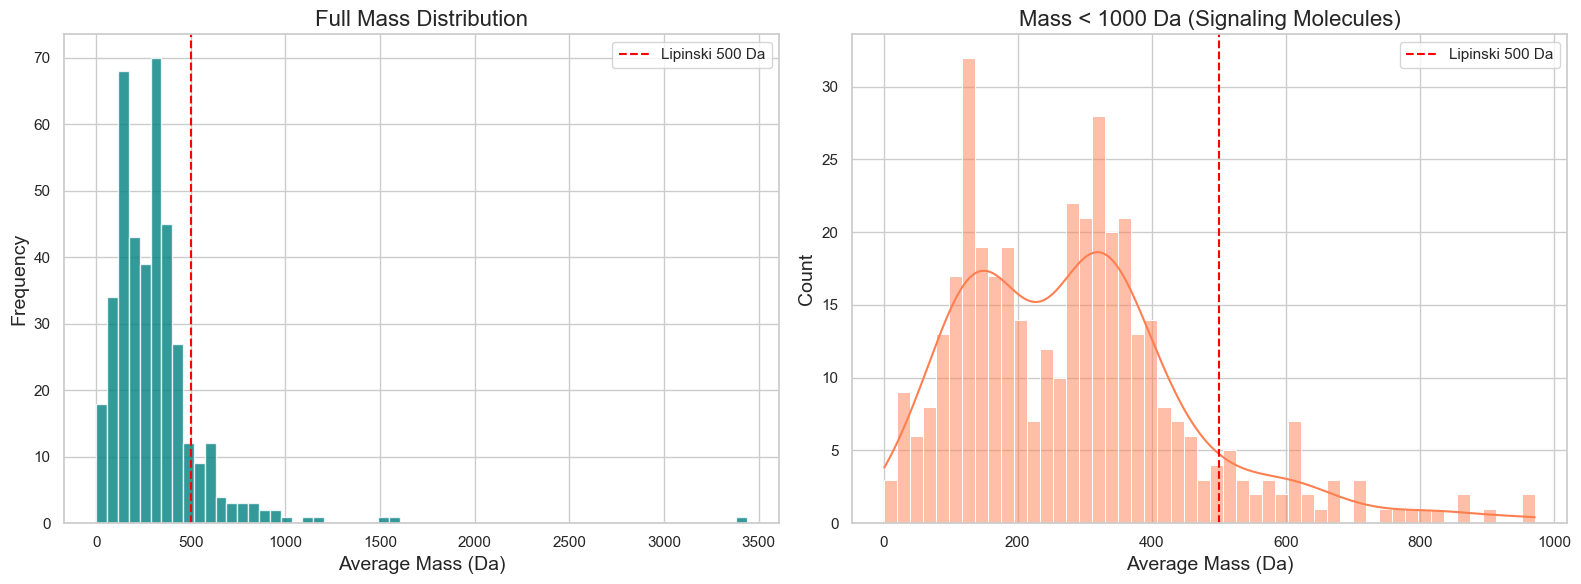


→ 352/400 (88.0%) metabolites are < 500 Da (typical small-molecule ligands).
→ Median mass: 286.4 Da
→ Range: 1.0 – 3438.0 Da


In [90]:
masses = df['AVERAGE_MASS'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full range histogram
ax = axes[0]
ax.hist(masses, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax.set_xlabel('Average Mass (Da)')
ax.set_ylabel('Frequency')
ax.set_title('Full Mass Distribution')
ax.legend()

# Focused range with KDE
ax2 = axes[1]
sns.histplot(masses[masses < 1000], bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax2.set_xlabel('Average Mass (Da)')
ax2.set_title('Mass < 1000 Da (Signaling Molecules)')
ax2.legend()

plt.tight_layout()
plt.show()

below500 = (masses < 500).sum()
print(f'\n→ {below500}/{len(masses)} ({below500/len(masses)*100:.1f}%) metabolites are < 500 Da (typical small-molecule ligands).')
print(f'→ Median mass: {masses.median():.1f} Da')
print(f'→ Range: {masses.min():.1f} – {masses.max():.1f} Da')

### 6.2. Elemental Composition Analysis
Parsing chemical formulas to understand the elemental diversity across all integrated metabolites.

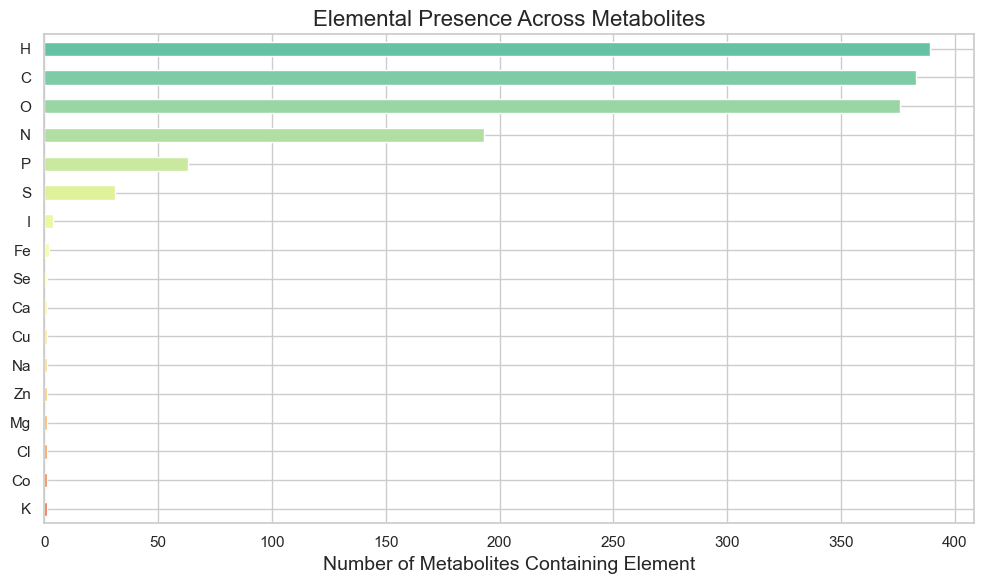


=== Heteroatom/Metal-Containing Metabolites ===
  S: 31 metabolites (7.7%)
  N: 193 metabolites (48.1%)
  P: 63 metabolites (15.7%)
  Cl: 1 metabolites (0.2%)
  I: 4 metabolites (1.0%)
  Se: 1 metabolites (0.2%)
  Fe: 2 metabolites (0.5%)
  Zn: 1 metabolites (0.2%)
  Cu: 1 metabolites (0.2%)
  Co: 1 metabolites (0.2%)


In [91]:
def parse_formula(formula):
    """Extract element counts from a chemical formula string."""
    if pd.isna(formula):
        return {}
    elements = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    return {el: int(count) if count else 1 for el, count in elements if el}

parsed = df['CHEMICAL_FORMULA'].apply(parse_formula)
all_elements = set()
for d in parsed:
    all_elements.update(d.keys())

# Count presence of each element
element_presence = {el: sum(1 for d in parsed if el in d) for el in all_elements}
element_series = pd.Series(element_presence).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
element_series.plot.barh(color=plt.cm.Spectral(np.linspace(0.2, 0.8, len(element_series))))
plt.xlabel('Number of Metabolites Containing Element')
plt.title('Elemental Presence Across Metabolites')
plt.tight_layout()
plt.show()

# Heteroatom analysis
heteroatoms = ['S', 'N', 'P', 'Cl', 'Br', 'I', 'Se', 'Fe', 'Zn', 'Cu', 'Co', 'Mn']
print('\n=== Heteroatom/Metal-Containing Metabolites ===')
for el in heteroatoms:
    count = element_presence.get(el, 0)
    if count > 0:
        print(f'  {el}: {count} metabolites ({count/len(df)*100:.1f}%)')

#### 🧬 TME Signaling & Cancer Connectome Insights:
- **Sulfur (S) — Present in ~7.7% of Metabolites**
  - **Redox Protection:** Extracellular Cysteine/Glutathione shuttle (protects cancer cells from ferroptosis/chemo).
  - **Gasotransmitters:** Hydrogen sulfide ($H_2S$) autocrine loops (promotes vascular remodeling).
- **Nitrogen (N) — Present in ~48.1% of Metabolites**
  - **Purinergic Signaling:** Adenosine $\rightarrow$ **$A_{2A}R$ / $A_{2B}R$** (primary T-cell/NK cell "off-switch").
  - **Amino Acid Exhaustion:** Kynurenine $\rightarrow$ **AHR** (drives $T_{reg}$ differentiation & tolerogenic dendritic cells).
- **Phosphorus (P) — Present in ~15.7% of Metabolites**
  - **Inflammatory DAMPs:** Extracellular ATP $\rightarrow$ **P2RX7 / P2RY** (triggers inflammasome & cell recruitment).
  - **Bioactive Lipids:** S1P & LPA $\rightarrow$ **S1PR1-5 / LPAR1-6** (orchestrates angiogenesis & cell migration).
- **Halogens (Cl, I) — Present in ~1.2% of Metabolites**
  - **Endocrine Regulators:** Thyroid hormones (T3/T4) $\rightarrow$ **$\alpha v\beta 3$ Integrin** (stimulates proliferation).
  - **Ion Shifts:** Extracellular Chloride shifts via GABA/Glutamate pathways (controls glioblastoma migration).
- **Selenium (Se) — Present in ~0.2% of Metabolites**
  - **ROS Modulators:** Selenoproteins (e.g., extracellular GPX) $\rightarrow$ alters ROS-mediated metastatic cascades.
- **Transition Metals (Fe, Zn, Cu, Co) — Present in ~1.1% of Metabolites**
  - **Iron (Fe):** Iron competition in TME $\rightarrow$ macrophage polarization (M1 vs M2) & ferroptosis.
  - **Copper (Cu):** **LOX** catalytic co-factor $\rightarrow$ crosslinks collagen to establish pre-metastatic niches.
  - **Zinc (Zn):** **MMP** zinc-finger engine $\rightarrow$ basement membrane degradation for cell invasion.
- **Carbon (C), Hydrogen (H), Oxygen (O) — Organic Scaffold**
  - **Lactate Pathway:** Lactate $\rightarrow$ **GPR81** (drives acidification, angiogenesis, & immune evasion).
  - **Lipid Mediators:** Prostaglandins (e.g., $PGE_2$) $\rightarrow$ **EP2/EP4 GPCRs** (mediates T-cell suppression).

### 6.3. Molecular Weight Classes & Communication Modes
Categorizing metabolites by mass bins to reveal physical diffusion characteristics and receptor interaction patterns.

#### 🎯 Biological Interpretation of MW Fingerprints:
- **Molecules < 300 Da (Paracrine Mode):** Ultra-fast local diffusion. Dominated by gasotransmitters, amino acids, and aromatic metabolic check-points (e.g., Lactate, Adenosine, Kynurenine).
- **Molecules 300 - 750 Da (GPCR & Hormonal Mode):** Highly specific, receptor-mediated pathways. Dominated by bioactive lipids and steroid hormones (e.g., S1P, LPA, prostaglandins).
- **Molecules > 750 Da (Juxtacrine & Vesicular Mode):** Slow diffusion. Dominated by membrane-bound structural anchors, phospholipids, and complex macrocycles (e.g., gangliosides, Vitamin B12).

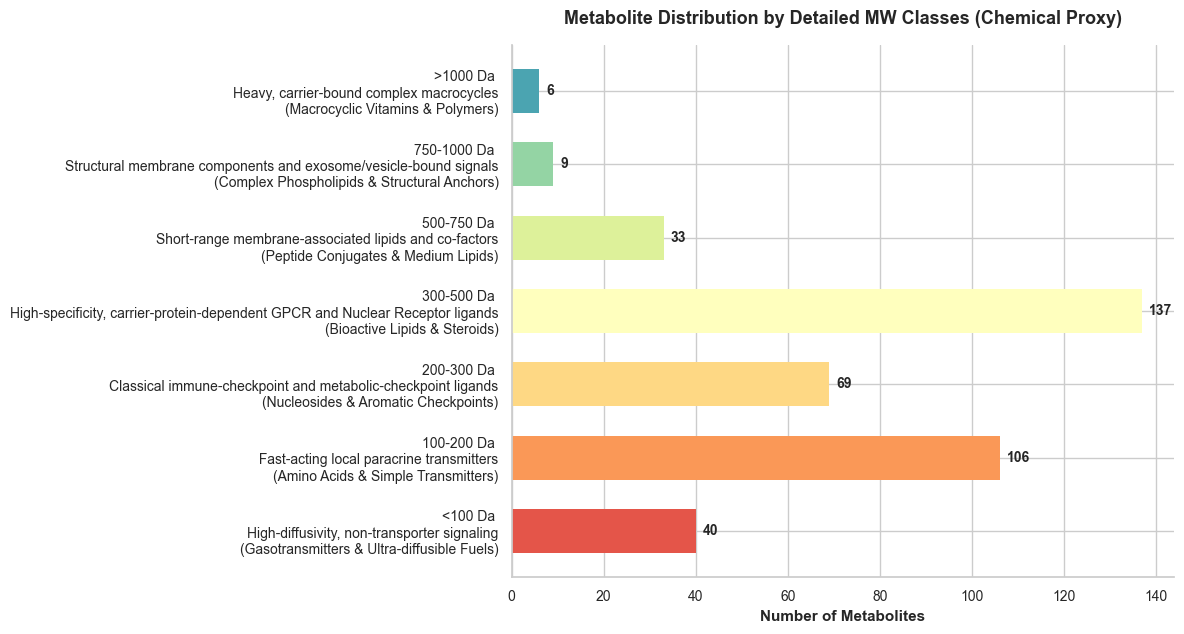

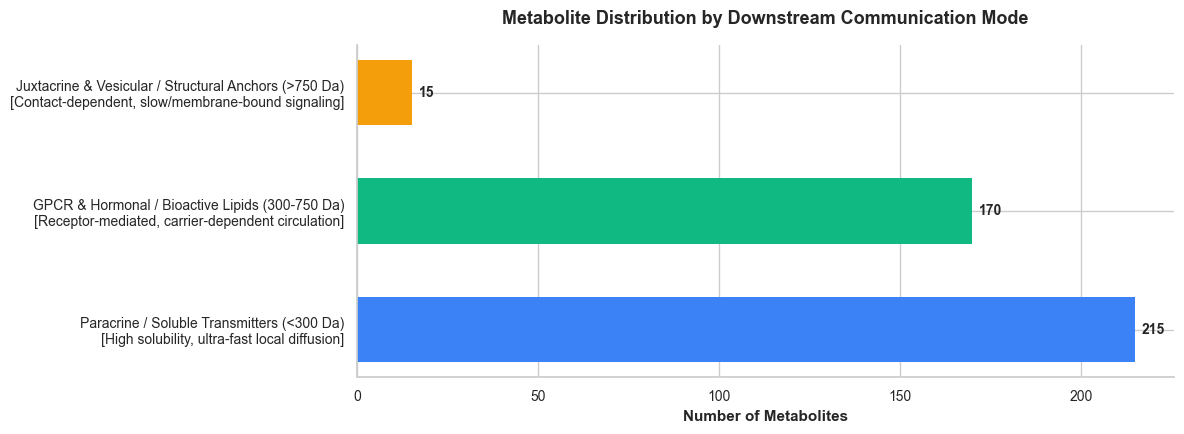


=== Database Breakdown by MW Class ===
  <100 Da (40 metabs): {'CELLINKER2': 28, 'MRCLINKDB': 28, 'MEBOCOST': 25, 'METALIGAND': 24, 'SCCELLFIE': 5, 'CELLPHONEDBV5': 1}
  100-200 Da (106 metabs): {'METALIGAND': 77, 'MEBOCOST': 63, 'CELLINKER2': 63, 'MRCLINKDB': 63, 'SCCELLFIE': 33, 'CELLPHONEDBV5': 10}
  200-300 Da (69 metabs): {'CELLINKER2': 45, 'MRCLINKDB': 45, 'MEBOCOST': 42, 'METALIGAND': 38, 'SCCELLFIE': 19, 'CELLPHONEDBV5': 8}
  300-500 Da (137 metabs): {'METALIGAND': 89, 'CELLINKER2': 85, 'MRCLINKDB': 85, 'MEBOCOST': 73, 'CELLPHONEDBV5': 24, 'SCCELLFIE': 15}
  500-750 Da (33 metabs): {'SCCELLFIE': 17, 'METALIGAND': 14, 'CELLINKER2': 14, 'MRCLINKDB': 14, 'MEBOCOST': 12, 'CELLPHONEDBV5': 2}
  750-1000 Da (9 metabs): {'SCCELLFIE': 7, 'METALIGAND': 2, 'CELLINKER2': 2, 'MRCLINKDB': 2, 'CELLPHONEDBV5': 1, 'MEBOCOST': 1}
  >1000 Da (6 metabs): {'CELLINKER2': 2, 'MRCLINKDB': 2, 'SCCELLFIE': 2, 'MEBOCOST': 1, 'CELLPHONEDBV5': 1, 'METALIGAND': 1}


In [92]:
# 1. Define bins and labels for detailed MW Classes
bins_mw = [0, 100, 200, 300, 500, 750, 1000, float('inf')]
labels_mw = ['<100', '100-200', '200-300', '300-500', '500-750', '750-1000', '>1000']
plot_labels_mw = [
    '<100 Da \nHigh-diffusivity, non-transporter signaling\n(Gasotransmitters & Ultra-diffusible Fuels)',
    '100-200 Da \n Fast-acting local paracrine transmitters\n(Amino Acids & Simple Transmitters)',
    '200-300 Da \nClassical immune-checkpoint and metabolic-checkpoint ligands\n(Nucleosides & Aromatic Checkpoints)',
    '300-500 Da \nHigh-specificity, carrier-protein-dependent GPCR and Nuclear Receptor ligands\n(Bioactive Lipids & Steroids)',
    '500-750 Da \nShort-range membrane-associated lipids and co-factors\n(Peptide Conjugates & Medium Lipids)',
    '750-1000 Da \nStructural membrane components and exosome/vesicle-bound signals\n(Complex Phospholipids & Structural Anchors)',
    '>1000 Da \nHeavy, carrier-bound complex macrocycles\n(Macrocyclic Vitamins & Polymers)'
]

df['MW_Class'] = pd.cut(df['AVERAGE_MASS'], bins=bins_mw, labels=labels_mw, right=False)
mw_counts = df['MW_Class'].value_counts().reindex(labels_mw)

# Plot 1: Detailed MW Classes (Horizontal Bar for Readability of Long Labels)
fig, ax = plt.subplots(figsize=(12, 6.5))
colors_mw = plt.cm.Spectral(np.linspace(0.15, 0.85, len(labels_mw)))
bars_mw = ax.barh(plot_labels_mw, mw_counts.values, color=colors_mw, edgecolor='none', height=0.6)

ax.set_xlabel('Number of Metabolites', fontsize=11, fontweight='semibold')
ax.set_title('Metabolite Distribution by Detailed MW Classes (Chemical Proxy)', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', which='major', labelsize=10)

# Add values at the end of each bar
for b in bars_mw:
    width = b.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    xy=(width, b.get_y() + b.get_height() / 2),
                    xytext=(5, 0),  # 5 points horizontal offset
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Define bins and labels for high-level Communication Modes (The Peaks)
bins_comm = [0, 300, 750, float('inf')]
labels_comm = ['Paracrine', 'GPCR/Hormonal', 'Juxtacrine/Vesicular']
plot_labels_comm = [
    'Paracrine / Soluble Transmitters (<300 Da)\n[High solubility, ultra-fast local diffusion]',
    'GPCR & Hormonal / Bioactive Lipids (300-750 Da)\n[Receptor-mediated, carrier-dependent circulation]',
    'Juxtacrine & Vesicular / Structural Anchors (>750 Da)\n[Contact-dependent, slow/membrane-bound signaling]'
]

df['Comm_Mode'] = pd.cut(df['AVERAGE_MASS'], bins=bins_comm, labels=labels_comm, right=False)
comm_counts = df['Comm_Mode'].value_counts().reindex(labels_comm)

# Plot 2: High-Level Communication Modes (Horizontal Bar)
fig, ax = plt.subplots(figsize=(12, 4.5))
colors_comm = ['#3b82f6', '#10b981', '#f59e0b']  # Sleek modern blue, emerald, amber palette
bars_comm = ax.barh(plot_labels_comm, comm_counts.values, color=colors_comm, edgecolor='none', height=0.55)

ax.set_xlabel('Number of Metabolites', fontsize=11, fontweight='semibold')
ax.set_title('Metabolite Distribution by Downstream Communication Mode', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', which='major', labelsize=10)

# Add values at the end of each bar
for b in bars_comm:
    width = b.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    xy=(width, b.get_y() + b.get_height() / 2),
                    xytext=(5, 0),  # 5 points horizontal offset
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Database Breakdown by MW Class for granular tracking
print('\n=== Database Breakdown by MW Class ===')
for mw_label in labels_mw:
    subset = df[df['MW_Class'] == mw_label]
    if len(subset) > 0:
        dbs = subset['database'].str.split(', ').explode().value_counts()
        print(f'  {mw_label} Da ({len(subset)} metabs): {dbs.to_dict()}')

# Cleanup temporary columns
df.drop(columns=['MW_Class', 'Comm_Mode'], inplace=True)


## 7. Confidence Tiers for Downstream Analysis

Assigning a confidence tier based on cross-database validation and annotation completeness. This provides a prioritization framework for selecting metabolites for downstream cell-cell communication (CCC) analysis.

| Confidence Tier | Database Overlap Criterion | Structural Requirements | Biological Signaling Significance |
| :--- | :--- | :--- | :--- |
| **Tier 1 (High)** | Overlap in $\ge$ 4 databases | Both SMILES & Average Mass present | High-confidence, widely cross-validated extracellular signaling ligands |
| **Tier 2 (Medium)** | Overlap in 2-3 databases | SMILES present | Moderately validated signaling metabolites |
| **Tier 3 (Low)** | Found in exactly 1 database | Any | Single-source, unvalidated metabolites (highly unique to specific platforms) |

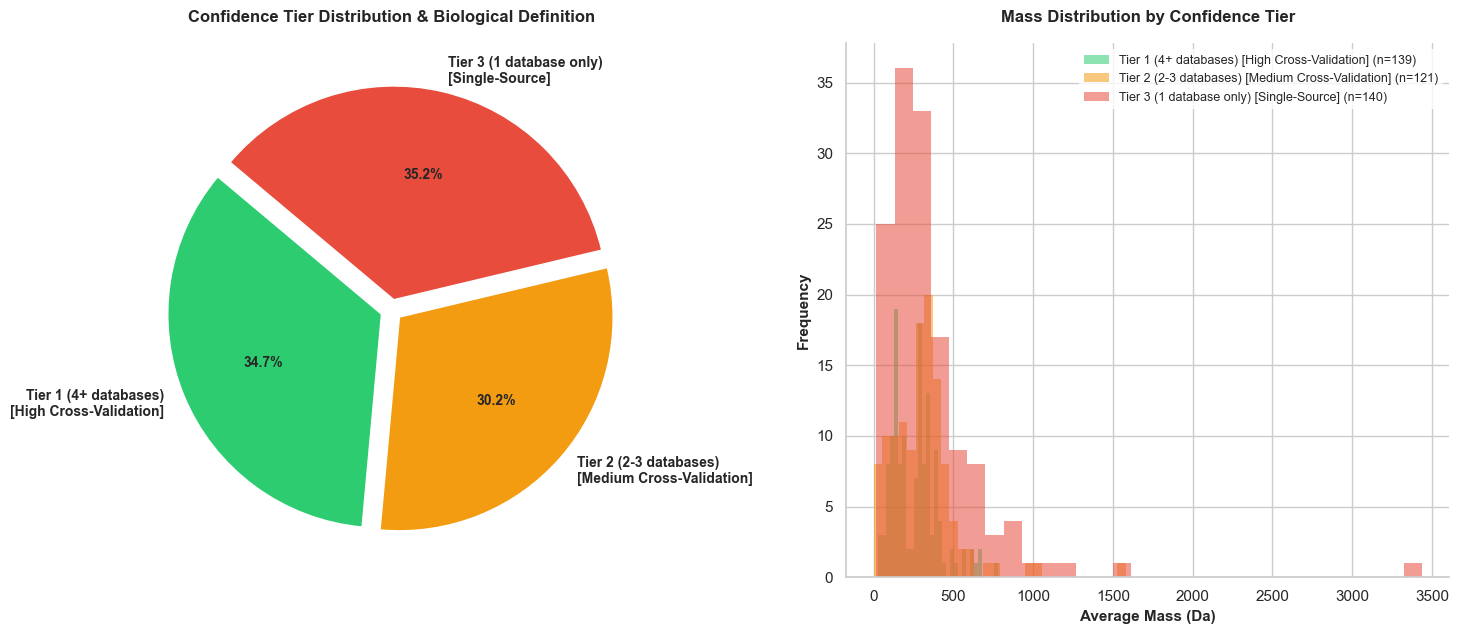


=== Confidence Tier Summary ===
  * Tier 1 (High - Overlap in 4+ databases, widely cross-validated): 139 metabolites (34.7%)
  * Tier 2 (Medium - Overlap in 2-3 databases, mainly CELLINKER2/MRCLINKDB): 121 metabolites (30.2%)
  * Tier 3 (Low - Found in only 1 database, mainly METALIGAND/SCCELLFIE): 141 metabolites (35.2%)

→ Tier 1 metabolites are recommended as the primary high-confidence set for TCGA/scRNAseq integration.


In [93]:
# 1. Assign Tiers based on strict multi-database overlap and structure completeness
def assign_tier(row):
    score = row['databases_count']
    has_smiles = pd.notna(row['SMILES'])
    has_mass = pd.notna(row['AVERAGE_MASS'])
    if score >= 4 and has_smiles and has_mass:
        return 'Tier 1 (High)'
    elif score >= 2 and has_smiles:
        return 'Tier 2 (Medium)'
    else:
        return 'Tier 3 (Low)'

df['Confidence_Tier'] = df.apply(assign_tier, axis=1)
tier_counts = df['Confidence_Tier'].value_counts()

# 2. Audit each tier dynamically to extract structural and source properties
tier_info = {}
for tier_name in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']:
    sub = df[df['Confidence_Tier'] == tier_name]
    n = len(sub)
    pct = (n / len(df)) * 100
    
    # Database overlap details
    dbs_sorted = sub['database'].str.split(', ').explode().value_counts()
    top_dbs = "/".join(dbs_sorted.head(2).index)
    
    if tier_name == 'Tier 1 (High)':
        desc = f"Tier 1 (High - Overlap in 4+ databases, widely cross-validated): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 1 (4+ databases)\n[High Cross-Validation]"
    elif tier_name == 'Tier 2 (Medium)':
        desc = f"Tier 2 (Medium - Overlap in 2-3 databases, mainly {top_dbs}): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 2 (2-3 databases)\n[Medium Cross-Validation]"
    else:
        desc = f"Tier 3 (Low - Found in only 1 database, mainly {top_dbs}): {n} metabolites ({pct:.1f}%)"
        short_label = f"Tier 3 (1 database only)\n[Single-Source]"
        
    tier_info[tier_name] = {
        'count': n,
        'pct': pct,
        'desc': desc,
        'short_label': short_label,
        'masses': sub['AVERAGE_MASS'].dropna()
    }

# 3. Create plotting visualization with detailed descriptions
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Slice mapping for the pie chart
labels_pie = [tier_info[t]['short_label'] for t in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']]
counts_pie = [tier_info[t]['count'] for t in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']]
tier_colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(counts_pie, labels=labels_pie, autopct='%1.1f%%',
            colors=tier_colors, startangle=140, explode=[0.05]*3,
            textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Confidence Tier Distribution & Biological Definition', fontsize=12, fontweight='bold', pad=15)

# Mass distribution histogram by tier
for i, tier in enumerate(['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']):
    masses = tier_info[tier]['masses']
    if len(masses) > 0:
        clean_label = tier_info[tier]['short_label'].replace('\n', ' ')
        axes[1].hist(masses, bins=30, alpha=0.55, 
                     label=f"{clean_label} (n={len(masses)})", 
                     color=tier_colors[i], edgecolor='none')
                     
axes[1].set_xlabel('Average Mass (Da)', fontsize=11, fontweight='semibold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='semibold')
axes[1].set_title('Mass Distribution by Confidence Tier', fontsize=12, fontweight='bold', pad=15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#cccccc')
axes[1].spines['bottom'].set_color('#cccccc')
axes[1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)

plt.tight_layout()
plt.show()

# 4. Print beautiful, explicit summary of the tiers
print('\n=== Confidence Tier Summary ===')
for tier in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']:
    print(f"  * {tier_info[tier]['desc']}")

print(f'\n→ Tier 1 metabolites are recommended as the primary high-confidence set for TCGA/scRNAseq integration.')

# Cleanup


---

## 8. Summary Table: Key Metabolite Catalog Statistics

In [94]:
summary = {
    'Total unique metabolites': len(df),
    'With HMDB ID': df['HMDB_ID'].notna().sum(),
    'With SMILES': df['SMILES'].notna().sum(),
    'With chemical formula': df['CHEMICAL_FORMULA'].notna().sum(),
    'Median mass (Da)': f"{df['AVERAGE_MASS'].median():.1f}",
    'In 1 database only': (df['databases_count'] == 1).sum(),
    'In 2+ databases': (df['databases_count'] >= 2).sum(),
    'In 3+ databases (high confidence)': (df['databases_count'] >= 3).sum(),
    'In all 6 databases': (df['databases_count'] == 6).sum(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

,Value
Total unique metabolites,401
With HMDB ID,401
With SMILES,401
With chemical formula,401
Median mass (Da),286.4
In 1 database only,141
In 2+ databases,260
In 3+ databases (high confidence),217
In all 6 databases,9


---

## 9. High-Confidence Tier 1 Metabolites Export

Extracting and exporting the highly cross-validated Tier 1 metabolites for downstream cell-cell communication (CCC) target-pair mapping.

In [95]:
# 1. Extract Tier 1 (High Confidence) metabolites
df_tier1 = df[df['Confidence_Tier'] == 'Tier 1 (High)'].copy()

# 2. Define the output file path
output_path = '../output/human_database_merge_unique_metab_tier1.csv'

# 3. Save the high-confidence dataset
df_tier1.to_csv(output_path, index=False)

print(f"🎉 Successfully exported {len(df_tier1)} high-confidence Tier 1 metabolites to:")
print(f"   -> '{output_path}'")

# 4. Display the top 15 Tier 1 metabolites as a catalog preview
df_preview = df_tier1[['Metabolite_Name', 'HMDB_Name', 'databases_count', 'SMILES', 'AVERAGE_MASS']].head(15)
df_preview


🎉 Successfully exported 139 high-confidence Tier 1 metabolites to:
   -> '../output/human_database_merge_unique_metab_tier1.csv'


,Metabolite_Name,HMDB_Name,databases_count,SMILES,AVERAGE_MASS
9,12-hydroxyeicosatetraenoic acid,12-HETE,4,CCCCC\C=C/C[C@H](O)\C=C\C=C/C\C=C/CCCC(O)=O,320.4663
12,13-cis-retinoic acid,13-cis-Retinoic acid,4,C\C(\C=C\C1=C(C)CCCC1(C)C)=C/C=C/C(/C)=C\C(O)=O,300.4351
20,2-arachidonoylglycerol,"MG(0:0/20:4(5Z,8Z,11Z,14Z)/0:0)",5,[H]C(CO)(CO)OC(=O)CCC\C=C/C\C=C/C\C=C/C\C=C/CCCCC,378.5454
21,2-hydroxyestradiol,2-Hydroxyestradiol,4,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@]1([H])C3=C(...,288.3814
26,20-hydroxy-leukotriene b4,20-Hydroxy-leukotriene B4,4,OCCCCC\C=C/C[C@@H](O)\C=C\C=C\C=C/[C@@H](O)CCC...,352.4651
29,24-hydroxycholesterol,24-Hydroxycholesterol,4,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,402.6529
30,25-hydroxycholesterol,25-Hydroxycholesterol,4,[H]C12CC[C@H]([C@H](C)CCCC(C)(C)O)[C@@]1(C)CCC...,402.6529
31,27-hydroxycholesterol,27-Hydroxycholesterol,4,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4C[C@@H](...,402.6529
36,3-methoxytyramine,3-Methoxytyramine,4,COC1=C(O)C=CC(CCN)=C1,167.2050
40,5(s)-hydroperoxyeicosatetraenoic acid,5(S)-Hydroperoxyeicosatetraenoic acid,5,CCCCC\C=C/C\C=C/C\C=C/C=C/[C@H](CCCC(O)=O)OO,336.4657


In [96]:
# 1. Extract Tier 1 (High Confidence) metabolites
df_tier2 = df[df['Confidence_Tier'] == 'Tier 2 (Medium)'].copy()

# 2. Define the output file path
output_path = '../output/human_database_merge_unique_metab_tier2.csv'

# 3. Save the high-confidence dataset
df_tier2.to_csv(output_path, index=False)

print(f"🎉 Successfully exported {len(df_tier1)} medium-confidence Tier 2 metabolites to:")
print(f"   -> '{output_path}'")

# 4. Display the top 15 Tier 1 metabolites as a catalog preview
df_preview = df_tier2[['Metabolite_Name', 'HMDB_Name', 'databases_count', 'SMILES', 'AVERAGE_MASS']].head(15)
df_preview


🎉 Successfully exported 139 medium-confidence Tier 2 metabolites to:
   -> '../output/human_database_merge_unique_metab_tier2.csv'


,Metabolite_Name,HMDB_Name,databases_count,SMILES,AVERAGE_MASS
0,(r)-5-diphosphomevalonic acid,(R)-5-Diphosphomevalonic acid,3,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,308.1169
2,"1,25-dihydroxyvitamin d3-26,23-lactone","1,25-Dihydroxyvitamin D3-26,23-lactone",2,[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,444.6035
4,11-cis-retinol,11-cis-Retinol,3,C\C(=C/CO)\C=C/C=C(\C)/C=C/C1=C(C)CCCC1(C)C,286.4516
8,12(s)-leukotriene b4,12(S)-Leukotriene B4,2,CCCCC\C=C/C[C@H](O)\C=C\C=C\C=C/[C@@H](O)CCCC(...,336.4657
10,12-oxo-leukotriene b4,12-Keto-leukotriene B4,2,CCCCC\C=C/CC(=O)\C=C\C=C\C=C/[C@@H](O)CCCC(O)=O,334.4498
11,12s-hydroxyheptadecatrienoic acid,12S-HHT,3,CCCCC[C@H](O)\C=C\C=C\C\C=C/CCCC(O)=O,280.4024
14,"15-deoxy-d-12,14-prostaglandin j2","15-Deoxy-d-12,14-PGJ2",3,CCCCC\C=C\C=C1/[C@@H](C\C=C/CCCC(O)=O)C=CC1=O,316.4345
16,15-hydroxyeicosatetraenoic acid,15-HETE,3,CCCCC[C@H](O)\C=C\C=C/C\C=C/C\C=C/CCCC(O)=O,320.4663
27,20-hydroxyeicosatetraenoic acid,20-Hydroxyeicosatetraenoic acid,2,OCCCCC\C=C/C\C=C/C\C=C/C\C=C/CCCC(O)=O,320.4663
28,22b-hydroxycholesterol,22b-Hydroxycholesterol,3,[H][C@@]12CC[C@H]([C@H](C)[C@H](O)CCC(C)C)[C@@...,402.6529


---

## 10. Export Visualizations to PDF

Compiling all generated metabolite characterization figures, cross-database validation curves, database intersection Venn/UpSets, elemental/molecular weight distributions, and confidence tier plots into a single, cohesive, high-resolution multi-page PDF report.

---

## 10. Export Full Notebook Report to HTML

Compiling this entire interactive notebook—including all documentation, code blocks, raw output tables, and high-resolution plots—into a single publication-ready HTML report.

---

## 10. Export Full Notebook Report to HTML

Compiling this entire interactive notebook—including all structured explanations, executable code blocks, data tables, and high-resolution plots—into a single publication-ready and highly interactive HTML report.

In [ ]:
# ==========================================
# 📄 FULL NOTEBOOK HTML REPORT EXPORT
# ==========================================
if 'SAVE_AS_HTML' in globals() and SAVE_AS_HTML:
    import subprocess
    import os
    
    notebook_filename = 'unique_metab_data_exploration.ipynb'
    output_html = '../output/unique_metab_data_exploration_full_report.html'
    
    print(f"Executing full notebook HTML export for '{notebook_filename}'...")
    
    # Export to beautiful styled HTML
    print("Generating gorgeous, styling-preserved HTML report...")
    cmd_html = [
        'jupyter', 'nbconvert', '--to', 'html', 
        notebook_filename, '--output', output_html
    ]
    res_html = subprocess.run(cmd_html, capture_output=True, text=True)
    
    if res_html.returncode == 0:
        print(f"🎉 SUCCESS: Notebook successfully exported as a styled HTML report!")
        print(f"   -> Saved to: '{output_html}'")
        print("\n💡 Tip: You can open this HTML file in any web browser to view, share, or print to PDF (Cmd+P)!")
    else:
        print("❌ HTML export failed. Error details:")
        print(res_html.stderr)
else:
    print("Full notebook HTML export is currently disabled. Set SAVE_AS_HTML = True in parameters at the top to compile the report!")